# Iris: DBSCAN Clustering and Outlier Detection

## Project Overview

This notebook applies density-based clustering to the Iris dataset and uses DBSCAN's noise label to identify observations that do not belong to the dense regions found under the selected parameters.

### Technical Coverage

- DBSCAN
- density-based clustering
- `eps` neighborhood radius
- `min_samples`
- cluster labels
- noise/outlier identification
- tabular feature extraction
- two-dimensional cluster visualization

## 1. Environment

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

## 2. Iris Data

The four numerical measurements are used as clustering features, while the species column is retained in the dataframe for reference.

In [10]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

iris = pd.read_csv(
    io.BytesIO(next(iter(uploaded.values()))),
)

iris.head()

Saving iris.csv to iris (4).csv


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


### Column Names

In [11]:
iris.columns = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width', 'Species']
iris.head()

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


### Feature Matrix

In [12]:
X = iris[['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']].values

y = iris['Species'].values

X[0:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

## 3. DBSCAN Model

The model uses:

```text
eps = 0.8
min_samples = 19
```

DBSCAN assigns dense-region cluster identifiers and uses `-1` for observations classified as noise.

In [13]:
model = DBSCAN(eps=0.8, min_samples=19)
model.fit(X)
print(model)

DBSCAN(eps=0.8, min_samples=19)


### Cluster and Noise Labels

In [14]:
model.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

## 4. Identified Outliers

The observations assigned the `-1` label are extracted directly from the feature matrix.

In [15]:
outliers_df = pd.DataFrame(X)

print(outliers_df[model.labels_ == -1])

       0    1    2    3
98   5.1  2.5  3.0  1.1
105  7.6  3.0  6.6  2.1
117  7.7  3.8  6.7  2.2
118  7.7  2.6  6.9  2.3
122  7.7  2.8  6.7  2.0
131  7.9  3.8  6.4  2.0


The saved run identifies six noise observations at indices **98, 105, 117, 118, 122, and 131**.

## 5. Cluster Visualization

Petal length and sepal width are displayed in two dimensions, with point colors determined by the DBSCAN labels.

Text(0.5, 1.0, 'DBSCAN for Outlier Detection')

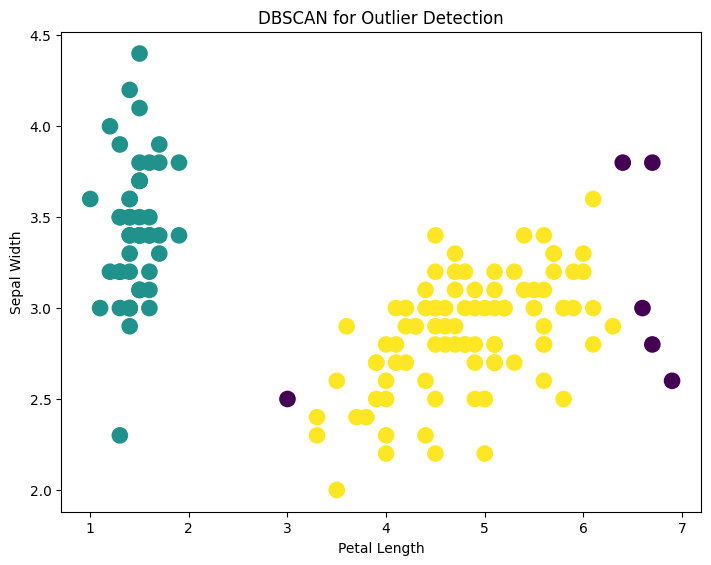

In [16]:
fig = plt.figure()
ax = fig.add_axes([.1, .1, 1, 1])

colors = model.labels_

ax.scatter(X[:, 2], X[:, 1], c=colors, s=120)
ax.set_xlabel("Petal Length")
ax.set_ylabel("Sepal Width")
plt.title("DBSCAN for Outlier Detection")

## 6. Key Findings

- DBSCAN separates dense regions without requiring a predefined number of clusters.
- Under `eps=0.8` and `min_samples=19`, the saved model produces two dense cluster labels plus six noise observations.
- The `-1` label provides a direct mechanism for identifying low-density points.
- The two-dimensional visualization provides an interpretable view of the density-based assignments while the model itself uses all four numerical Iris features.